In [45]:
from pathlib import Path
import pandas as pd
import numpy as np

## Preprocessed Bereich:

#### .npy-Datei von 001-000 aus dem Ordner Inductive_Probes:

In [46]:
data = np.load("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")

In [47]:
print(type(data))
print(data.shape)
print(data.dtype)
print(data[:, -1]) # letzte

<class 'numpy.ndarray'>
(4, 19909)
float64
[21.042       0.02830047  0.23695214  0.56079739]


#### von 001-000 sound .tiff Dateien aus dem Ordner LWIR/Labeled_Frames:

In [48]:
import matplotlib.pyplot as plt
from PIL import Image
import math

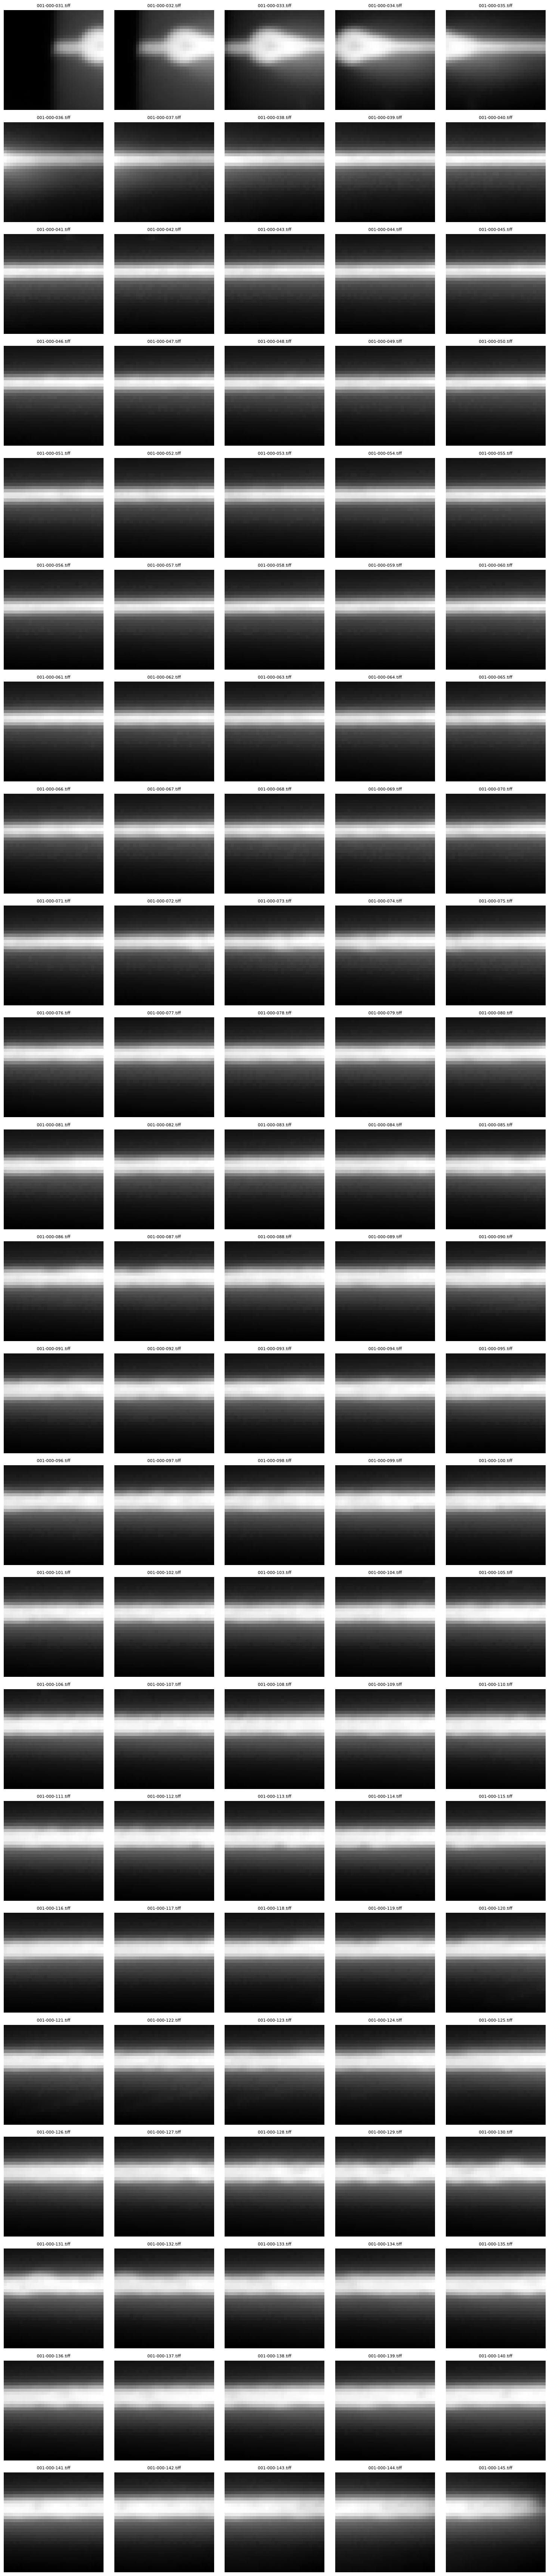

In [49]:
pfadSound = Path(
    "../data/Dataset/Preprocessed/LWIR/Labeled_Frames/001-000/sound"
)

soundFrames = sorted(pfadSound.glob("*.tiff"))

spalten = 5
zeilen = math.ceil(len(soundFrames) / spalten)

plt.figure(figsize = (15, zeilen * 3))

for i, frame in enumerate(soundFrames, start = 1):
    img = Image.open(frame)
    imgArray = np.array(img)

    plt.subplot(zeilen, spalten, i)
    plt.imshow(imgArray, cmap = "gray")
    plt.title(frame.name, fontsize = 8)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### von 001-000 unsound .tiff Dateien dem Ordner LWIR/Labeled_Frames:

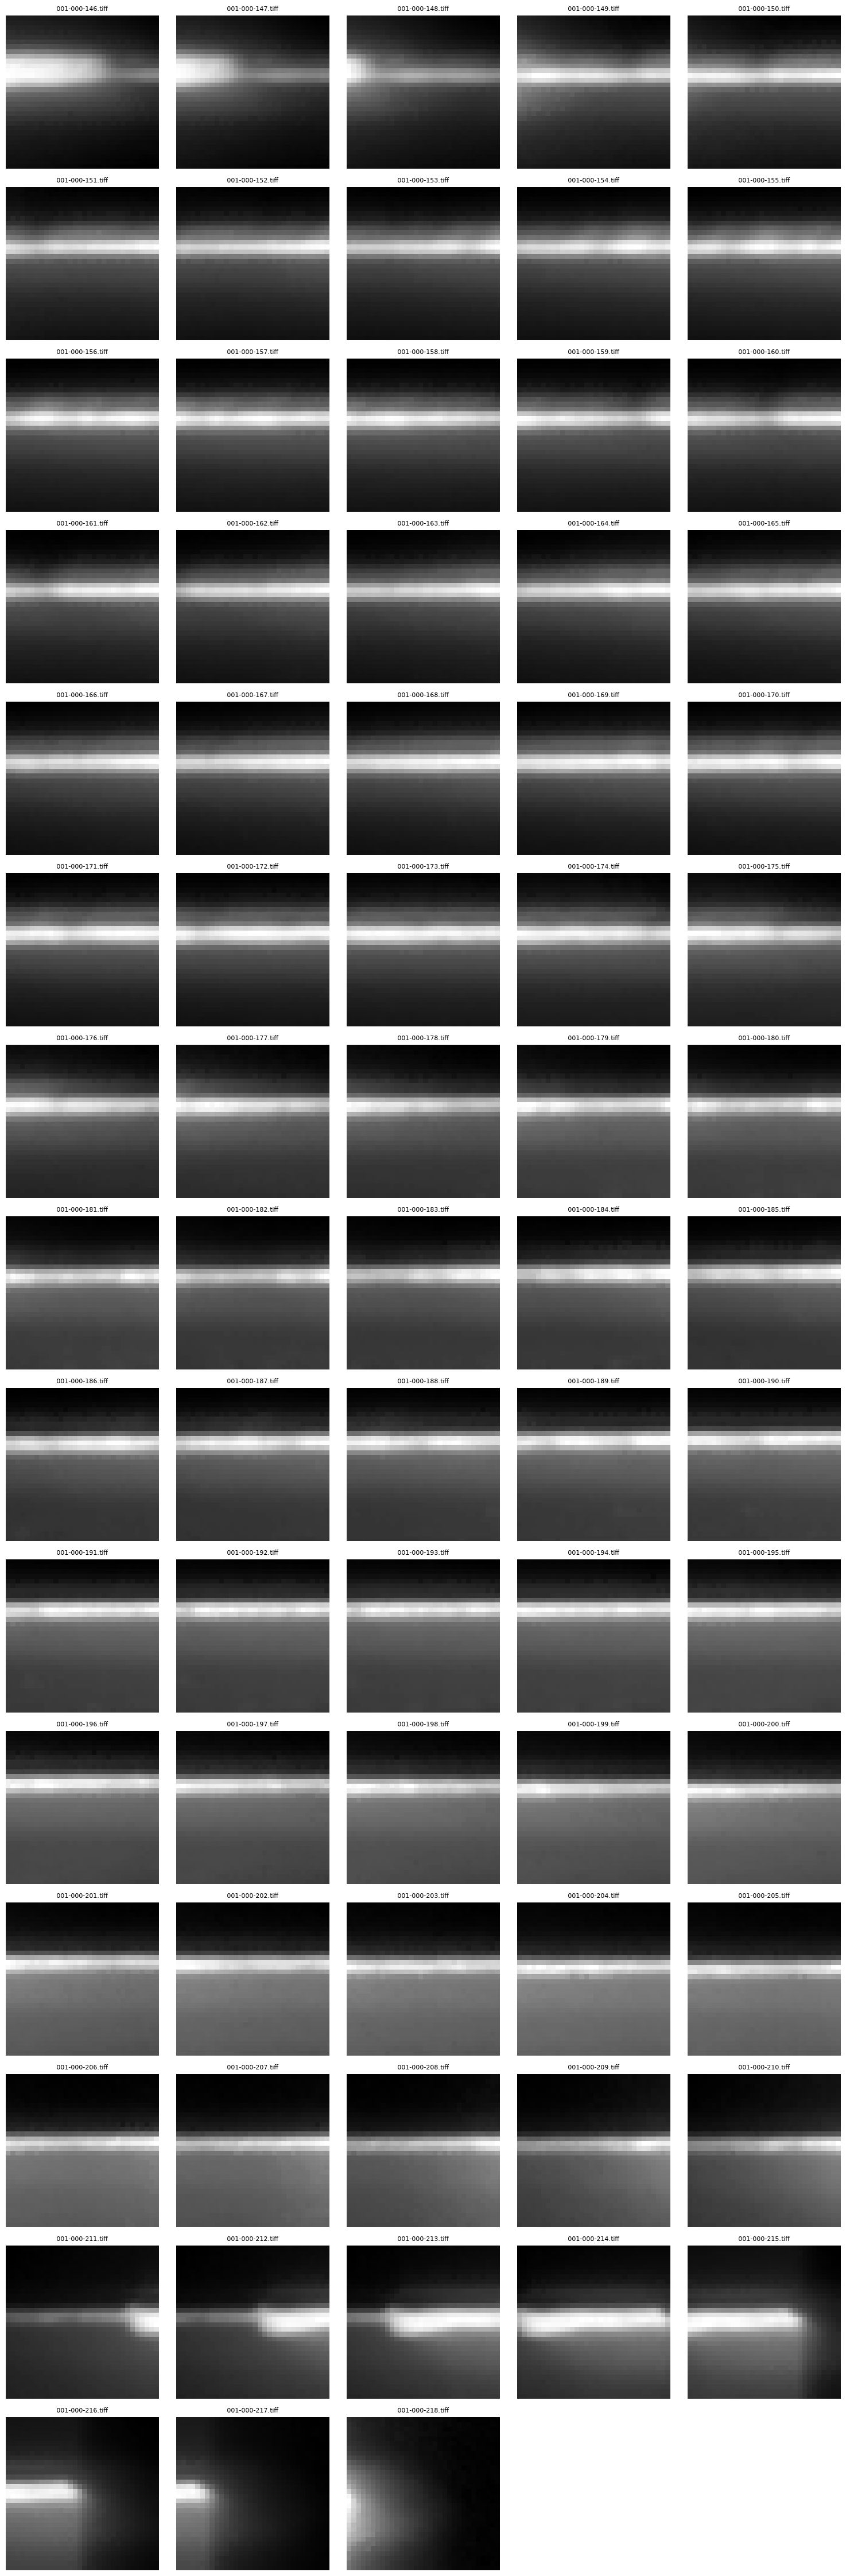

In [50]:
pfadUnsound = Path(
    "../data/Dataset/Preprocessed/LWIR/Labeled_Frames/001-000/unsound"
)

unsoundFrames = sorted(pfadUnsound.glob("*.tiff"))

anzahl = len(unsoundFrames)
spalten = 5
zeilen = math.ceil(anzahl / spalten)

plt.figure(figsize=(15, zeilen * 3))

for i, frame in enumerate(unsoundFrames, start=1):
    img = Image.open(frame)
    imgArray = np.array(img)

    plt.subplot(zeilen, spalten, i)
    plt.imshow(imgArray, cmap = "gray")
    plt.title(frame.name, fontsize = 8)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### 001-000.cvs Datei aus dem Ordner LWIR/Labels:

In [61]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

pfadLabelsCSV001_000 = Path("../data/Dataset/Preprocessed/LWIR/Labels/001-000.csv")

csvLabels001_000 = pd.read_csv(
    pfadLabelsCSV001_000
)

display(csvLabels001_000)

,Unnamed: 0,Frame,Label
0,0,0,Beginning
1,1,1,Beginning
2,2,2,Beginning
3,3,3,Beginning
4,4,4,Beginning
5,5,5,Beginning
6,6,6,Beginning
7,7,7,Beginning
8,8,8,Beginning
9,9,9,Beginning


##### Bei sound ging im 001-000 Ordner ab 031 los, und unsound ab 146.

## Raw Bereich:

#### .csv-Datei von 001-000:

In [52]:
pfadCSV001_000 = Path("../data/Dataset/Raw/inductive_Probes/001/001-000.csv")

CSV001_000 = pd.read_csv(
    pfadCSV001_000
)

display(CSV001_000.tail(1)) # letzte

print(CSV001_000.shape)

,Time (s),Trigger (V),Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
21043,21.043,24.014523,0.028143,0.237031,0.560954


(21044, 5)


## Schnittstellen:

In [53]:
# Zeit stimmt nicht überein zwischen Raw und Preprocessed beim letzten, deshalb schauen:

raw21042 = CSV001_000[
    CSV001_000["Time (s)"] == 21.042
]

display(raw21042)

print(data[:, -1])

,Time (s),Trigger (V),Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
21042,21.042,24.072506,0.0283,0.236952,0.560797


[21.042       0.02830047  0.23695214  0.56079739]


##### Grund:

##### Preprocessed bedeutet, dass die Daten verändert oder ausgeschnitten wurden. Die .npy muss also nicht bis exakt zur letzten Raw Zeile gehen. Die letzte .npy Zeile muss also nicht die letzte .csv Zeile entsprechen, entspricht eher die vorletzte .csv Zeile.

## Notizen:

- 001 ist die langsamere SchweißKonfiguration, 002 die schnellere.
- 001 ca. 1 m/min Schweizgeschwindigkeit und 002 5 m/min Schweißgeschwindigkeit, etwa 5 mal schneller
- Ordner Inductive_Probes enthält für jede Schweißung eine eigene CSV-Datei
- CSV besteht aus Time (s), Trigger (V), Taster 1 bis Taster 3
- Zeit wird in ms gezählt, ca. 1000Hz Abtastrate
- LWIR enthält für jede Schweißung eine bestimme Anzahl an .tiff-Dateien, diese sind einzelne LWIR-Wärmebilder
- Sound/Unsound bedeuten?
-  Labels?
-  Innerhalb Preprocessed, LWIR hat man Labeles_Frames-Ordner, dort für jede Schweißung sound- / unsound-Ordner
- `001-000(= Schweißung)/`
  - `sound/`
    - von `001-000-031.tiff`
    - bis `001-000-145.tiff`
  - `unsound/`
    - von `001-000-146.tiff`
    - bis `001-000-218.tiff`
- eine .tiff Datei ist ein Bild, ein Frame
- viele .tiff Dateien hintereinander bilden eine Bildsequenz
  - kurzen Film der Schweißung sozusagen